# COGS 108 - EDA Checkpoint

## Authors

**Ali Ahmed**: Background research, Writing - original draft, Data Curation, Visualization, Analysis, Software

**Rodayna Alnaggar**: Background research, Data curation, Visualization

**Tessa Kibbe**: Conceptualization, Writing - review & editing

**Sabine A Sanchez**: Data curation, Methodology, Analysis

**Maanav R Singh**: Project administration, Data curation, Software

# Research Question

Did the U.S. rollout of Google AI Overviews in May 2024 lead to a statistically significant decline in organic click-through rates from search engines to Wikipedia for informational topics — operationally defined as evergreen, encyclopedic Wikipedia articles (e.g. scientific concepts, historical events, and established entities) whose Google Trends search interest remained stable — when comparing the pre-rollout period (June 2023 – April 2024) to the post-rollout period (May 2024 – January 2025), using monthly Wikipedia Clickstream counts of search-originated transitions (`prev = 'other-search'`) as a proxy for organic clicks?


## Background and Prior Work

The way we search for information online is going through a huge change right now. For about 30 years, Google and other search engines worked pretty simply: you typed in a question, and they gave you a list of websites to click on. This "Ten Blue Links" model meant that users had to do the work of clicking through different sites, reading them, and figuring out what was true on their own. But now, with AI being added to search engines, things are different. Instead of just showing you where to find answers, search engines are now trying to give you the answer directly. Researchers call this shift moving from "Information Retrieval" to "Generative Information Retrieval."

This change didn't happen overnight, it built up over several years. In 2015, Google started using RankBrain; in 2019 they added BERT; in 2023 they launched the Search Generative Experience (SGE), which became "AI Overviews" in 2024. This was the first time Google actually showed AI-generated text at the top of search results instead of just links.

One major consequence is what researchers call the "Great Decoupling"—more people are searching than ever, but fewer people are actually clicking through to websites. Industry studies (e.g., Seer Interactive, Ahrefs) report that AI Overviews reduce organic click-through rates by roughly 50–60%. We are using Wikipedia Clickstream and Google Trends to test whether the introduction of AI Overviews is associated with a measurable shift in click-through behavior for informational queries.

# Hypothesis


We hypothesize that the rollout of Google AI Overviews in 2024 has caused a statistically significant shift in search behavior for informational queries, characterized by an increase in zero-click search rates and a corresponding decrease in organic click-through rates. We expect to see this change in proportions specifically in informational queries compared to navigational and transactional queries because they seek to find answers rather than destinations.

In addition, we hypothesize that the impact of AI Overviews on informational search behavior increased zero-click searches in a nonlinear pattern: modest changes immediately after rollout (lagged adoption), followed by a rapid increase as users grew more accustomed to relying on AI-generated summaries. This prediction is based on industry research showing that AI Overviews reduce organic clicks by 50–60% and the broader trend toward zero-click searches, suggesting users are increasingly accepting AI-generated answers without clicking through to verify information from original sources.

## Data

### Data overview

We use two datasets to proxy zero-click behavior: Wikipedia Clickstream (clicks from search to Wikipedia) and Google Trends (search interest over time). If search interest stays stable but clicks from Google to Wikipedia drop after AI Overviews, that gap supports an increase in zero-click behavior.

- **Dataset #1 – Wikipedia Clickstream**
  - **Dataset Name:** Wikimedia Clickstream (English Wikipedia, monthly)
  - **Link:** https://dumps.wikimedia.org/other/clickstream/
  - **Observations:** One row per (referrer, destination article) pair per month; millions of pairs per monthly file.
  - **Variables:** `prev` (referrer: e.g. "other-search" for search engines, or article title), `curr` (destination article), `type` (link/external/other), `n` (count of that transition).
  - **Relevance:** Filtering `prev = 'other-search'` gives monthly counts of clicks from search engines to Wikipedia articles. A decline in these counts after mid-2024, for informational articles, is consistent with more zero-click behavior.
  - **Shortcomings:** Aggregated; does not distinguish Google from other search engines; only captures traffic to Wikipedia; (referrer, resource) pairs with ≤10 observations are excluded.

- **Dataset #2 – Google Trends**
  - **Dataset Name:** Google Trends (interest over time)
  - **Link:** https://trends.google.com/ (or via `pytrends` in Python)
  - **Observations:** One row per date (or week) per keyword.
  - **Variables:** `date`, keyword (search term), `interest_over_time` (0–100, relative popularity).
  - **Relevance:** Shows whether people kept searching for the same topics across 2023–2025. Stable or rising interest with falling Wikipedia clickstream counts supports zero-click behavior.
  - **Shortcomings:** Relative scale (0–100), not absolute search volume; API/rate limits; sampling.

**Combining the datasets:** We align both datasets by **time** (month) and **topic**. We compute monthly clickstream counts from search to selected articles, get monthly Trends interest for matching keywords, and compare pre– vs post–AI Overviews periods.


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup: download raw data from source to data/00-raw/
# Only needs to be run once after cloning the repo.

import sys, os
sys.path.append('./modules')
import get_data

os.makedirs('data/00-raw', exist_ok=True)

datafiles = [
    {'url': 'https://dumps.wikimedia.org/other/clickstream/2023-06/clickstream-enwiki-2023-06.tsv.gz', 'filename': 'clickstream-enwiki-2023-06.tsv.gz'},
    {'url': 'https://dumps.wikimedia.org/other/clickstream/2024-06/clickstream-enwiki-2024-06.tsv.gz', 'filename': 'clickstream-enwiki-2024-06.tsv.gz'},
    {'url': 'https://dumps.wikimedia.org/other/clickstream/2025-01/clickstream-enwiki-2025-01.tsv.gz', 'filename': 'clickstream-enwiki-2025-01.tsv.gz'},
]
get_data.get_raw(datafiles, destination_directory='data/00-raw/')

### Wikipedia Clickstream (Dataset #1)

**Metrics and units:** Each row is a (referrer, resource) pair with count `n`. **prev**: referrer—either an article title (internal link) or a fixed code (e.g. `other-search` for external search engines, `other-external` for other external sites, `other-empty` for no referrer). **curr**: destination Wikipedia article (main namespace). **type**: `link` (prev links to curr), `external` (prev is external), or `other`. **n**: integer count of that (prev, curr) transition in that month. Pairs with 10 or fewer observations are excluded in the source. Counts are aggregated over desktop, mobile web, and mobile app.

**Relevance to the project:** Filtering rows where `prev == 'other-search'` gives monthly counts of clicks from search engines to Wikipedia articles. Summing `n` over selected informational articles (or over all articles) yields a proxy for "organic clicks from search to Wikipedia." A drop in this total after AI Overviews (2024) would be consistent with more zero-click behavior.

**Concerns:** Data is aggregated and anonymized; we cannot separate Google from other search engines. Only Wikipedia traffic is observed, so we are measuring one slice of organic clicks. Low-count pairs are dropped at source.

In [1]:
import os
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

os.makedirs('data/01-interim', exist_ok=True)
os.makedirs('data/02-processed', exist_ok=True)

raw_dir = 'data/00-raw'
pattern = os.path.join(raw_dir, 'clickstream-enwiki-*.tsv.gz')
files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError("No clickstream files found in data/00-raw/. Run the setup cell above to download them.")

dfs = []
for path in files:
    print(f"Loading {path} ...")
    basename = os.path.basename(path)
    month = basename.replace('clickstream-enwiki-', '').replace('.tsv.gz', '')
    df = pd.read_csv(
        path, sep='\t', compression='gzip',
        header=None, names=['prev', 'curr', 'type', 'n'],
        on_bad_lines='skip'
    )
    df['month'] = month
    dfs.append(df)

clickstream_raw = pd.concat(dfs, ignore_index=True)

print("Shape:", clickstream_raw.shape)
print("Columns:", clickstream_raw.columns.tolist())
display(clickstream_raw.head())

print("\nMissing per column:")
print(clickstream_raw.isnull().sum())

clickstream_raw = clickstream_raw.dropna(subset=['prev', 'curr', 'n'])

clickstream_search = clickstream_raw[clickstream_raw['prev'] == 'other-search'].copy()
print(f"\nRows with prev='other-search': {len(clickstream_search):,}")

clickstream_by_month = (
    clickstream_search.groupby(['month', 'curr'], as_index=False)['n']
    .sum()
    .rename(columns={'n': 'clicks_from_search'})
)
monthly_totals = clickstream_by_month.groupby('month', as_index=False)['clicks_from_search'].sum()
print("\nTotal clicks from search by month:")
display(monthly_totals)

clickstream_by_month.to_csv('data/02-processed/wikipedia_clickstream_search_by_month_article.csv', index=False)
monthly_totals.to_csv('data/02-processed/wikipedia_clickstream_search_monthly_totals.csv', index=False)
print("Saved to data/02-processed/")

Loading data/00-raw/clickstream-enwiki-2023-06.tsv.gz ...
Loading data/00-raw/clickstream-enwiki-2024-06.tsv.gz ...
Loading data/00-raw/clickstream-enwiki-2025-01.tsv.gz ...
Shape: (104239331, 5)
Columns: ['prev', 'curr', 'type', 'n', 'month']


,prev,curr,type,n,month
0,other-empty,Kensey_Johns_Jr.,external,32.0,2023-06
1,other-empty,Tengah_Islands,external,14.0,2023-06
2,other-search,Kensey_Johns_Jr.,external,17.0,2023-06
3,other-search,Tengah_Islands,external,10.0,2023-06
4,List_of_number-one_hits_of_1973_(Mexico),List_of_number-one_hits_of_1974_(Mexico),link,16.0,2023-06



Missing per column:
prev     108
curr     172
type       0
n         24
month      0
dtype: int64

Rows with prev='other-search': 11,725,119

Total clicks from search by month:


,month,clicks_from_search
0,2023-06,3.123554e+09
1,2024-06,2.955755e+09
2,2025-01,3.319773e+09


Saved to data/02-processed/


### Google Trends (Dataset #2)

**Metrics and units:** Google Trends provides **interest over time**: a 0–100 index of relative search popularity for a given keyword in a given time window (no absolute volume). We use weekly `date` and `interest` (0–100) per keyword.

**Relevance:** If Trends interest stays stable or rises while Wikipedia clickstream counts from search drop, that supports the hypothesis that more searches are "zero-click."

**Concerns:** Relative scale only; API/rate limits with `pytrends`; data is sampled.

**Obtaining the data:** We use the `pytrends` library to fetch interest over time for chosen keywords. Below we load or fetch the data and tidy it.

In [2]:
try:
    from pytrends.request import TrendReq
    pytrends_available = True
except ImportError:
    pytrends_available = False
    print("pytrends not installed. Install with: pip install pytrends")

if pytrends_available:
    pt = TrendReq(hl='en-US', tz=360)
    keywords = ["Quantum mechanics", "Climate change"]
    pt.build_payload(keywords, timeframe='2023-01-01 2025-02-01', geo='')
    trends_df = pt.interest_over_time()
    if 'isPartial' in trends_df.columns:
        trends_df = trends_df.drop(columns=['isPartial'])
    trends_df = trends_df.reset_index()
    trends_long = trends_df.melt(id_vars=['date'], var_name='keyword', value_name='interest')
    trends_long['month'] = trends_long['date'].dt.to_period('M').astype(str)
    print("Shape:", trends_long.shape)
    display(trends_long.head(10))
    trends_long.to_csv('data/02-processed/google_trends_interest_long.csv', index=False)
    print("\nSaved to data/02-processed/google_trends_interest_long.csv")
else:
    trends_path = 'data/02-processed/google_trends_interest_long.csv'
    if os.path.exists(trends_path):
        trends_long = pd.read_csv(trends_path)
        trends_long['date'] = pd.to_datetime(trends_long['date'])
        print("Loaded from existing processed file.")
        display(trends_long.head(10))
    else:
        trends_long = pd.DataFrame({'date': [], 'month': [], 'keyword': [], 'interest': []})
        print("No Google Trends data available. Install pytrends or place CSV in data/02-processed/")

Shape: (218, 4)


,date,keyword,interest,month
0,2023-01-01,Quantum mechanics,0,2023-01
1,2023-01-08,Quantum mechanics,0,2023-01
2,2023-01-15,Quantum mechanics,0,2023-01
3,2023-01-22,Quantum mechanics,0,2023-01
4,2023-01-29,Quantum mechanics,0,2023-01
5,2023-02-05,Quantum mechanics,0,2023-02
6,2023-02-12,Quantum mechanics,0,2023-02
7,2023-02-19,Quantum mechanics,0,2023-02
8,2023-02-26,Quantum mechanics,0,2023-02
9,2023-03-05,Quantum mechanics,0,2023-03



Saved to data/02-processed/google_trends_interest_long.csv


## Results

### Exploratory Data Analysis

Our EDA proceeds in three sections:

1. **Wikipedia Clickstream: Search Traffic Over Time (Context)** — We examine total and per-article search-originated clicks across our three monthly snapshots (June 2023, June 2024, January 2025). This section is descriptive context and is not, by itself, the operational test of our research question.
2. **Google Trends: Search Interest Stability** — We check stability for selected evergreen informational topics and apply an explicit stability criterion.
3. **Combined (Operationalized): Topic-Level Clicks vs Interest** — We restrict to evergreen topics with stable Trends behavior and compute a normalized metric (clicks per unit interest) for pre/post comparison.

We load the fully wrangled data from `data/02-processed/` so this section can be run independently of the slower data-loading cells above.


#### Section 1: Wikipedia Clickstream — Search Traffic Over Time

We first look at the total volume of search-originated clicks to English Wikipedia for each of our three monthly snapshots. This gives us the broadest view of whether organic traffic from search engines changed around the AI Overviews rollout (May 2024). We then drill into the top articles by search clicks to see if the pattern holds at the individual-topic level.

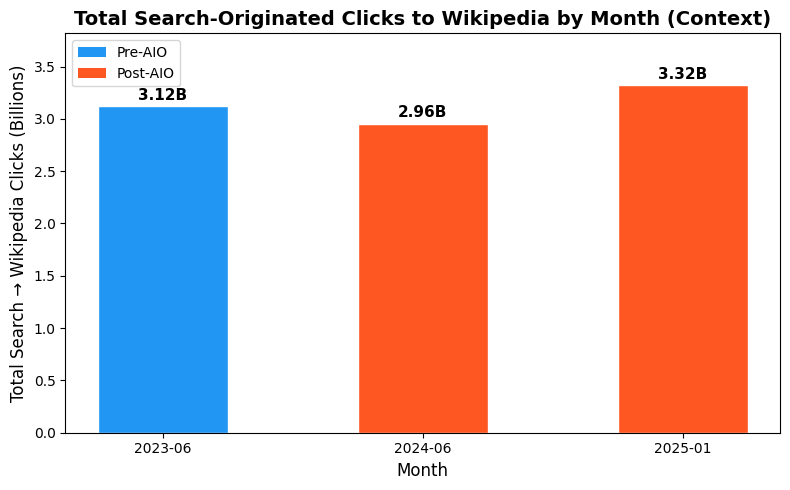

June 2023 (pre-AIO): 3.124B
June 2024 (post-AIO): 2.956B
Year-over-year change (June 2023 → June 2024): -5.37%
Note: this aggregate view is descriptive context, not the operational evergreen-topic test.


In [9]:
# Load processed clickstream data
cs_monthly = pd.read_csv('data/02-processed/wikipedia_clickstream_search_monthly_totals.csv')
cs_by_article = pd.read_csv('data/02-processed/wikipedia_clickstream_search_by_month_article.csv')

# ------- Figure 1: Total search clicks by month (context only) -------
fig, ax = plt.subplots(figsize=(8, 5))
period_colors = {'Pre-AIO': '#2196F3', 'Post-AIO': '#FF5722'}
cs_monthly['period'] = np.where(cs_monthly['month'] < '2024-05', 'Pre-AIO', 'Post-AIO')
bar_colors = cs_monthly['period'].map(period_colors)

bars = ax.bar(cs_monthly['month'], cs_monthly['clicks_from_search'] / 1e9, color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, cs_monthly['clicks_from_search']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val/1e9:.2f}B', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Search → Wikipedia Clicks (Billions)', fontsize=12)
ax.set_title('Total Search-Originated Clicks to Wikipedia by Month (Context)', fontsize=14, fontweight='bold')
ax.set_ylim(0, cs_monthly['clicks_from_search'].max() / 1e9 * 1.15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Pre-AIO'), Patch(facecolor='#FF5722', label='Post-AIO')]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

print("June 2023 (pre-AIO):", f"{cs_monthly.loc[cs_monthly['month']=='2023-06', 'clicks_from_search'].values[0]/1e9:.3f}B")
print("June 2024 (post-AIO):", f"{cs_monthly.loc[cs_monthly['month']=='2024-06', 'clicks_from_search'].values[0]/1e9:.3f}B")
pct_change = ((cs_monthly.loc[cs_monthly['month']=='2024-06', 'clicks_from_search'].values[0] - 
                cs_monthly.loc[cs_monthly['month']=='2023-06', 'clicks_from_search'].values[0]) / 
               cs_monthly.loc[cs_monthly['month']=='2023-06', 'clicks_from_search'].values[0] * 100)
print(f"Year-over-year change (June 2023 → June 2024): {pct_change:+.2f}%")
print("Note: this aggregate view is descriptive context, not the operational evergreen-topic test.")

The bar chart above shows a modest decline in total search-to-Wikipedia clicks from June 2023 to June 2024, followed by a rebound in January 2025. However, comparing just two June months controls for seasonality, and the ~5% drop from 2023 to 2024 is directionally consistent with the hypothesis. January 2025 is a different month, so seasonal effects could explain its higher value.

Next, we look at the top 15 articles by search clicks in each period to see whether the pattern is broad or driven by specific topics.

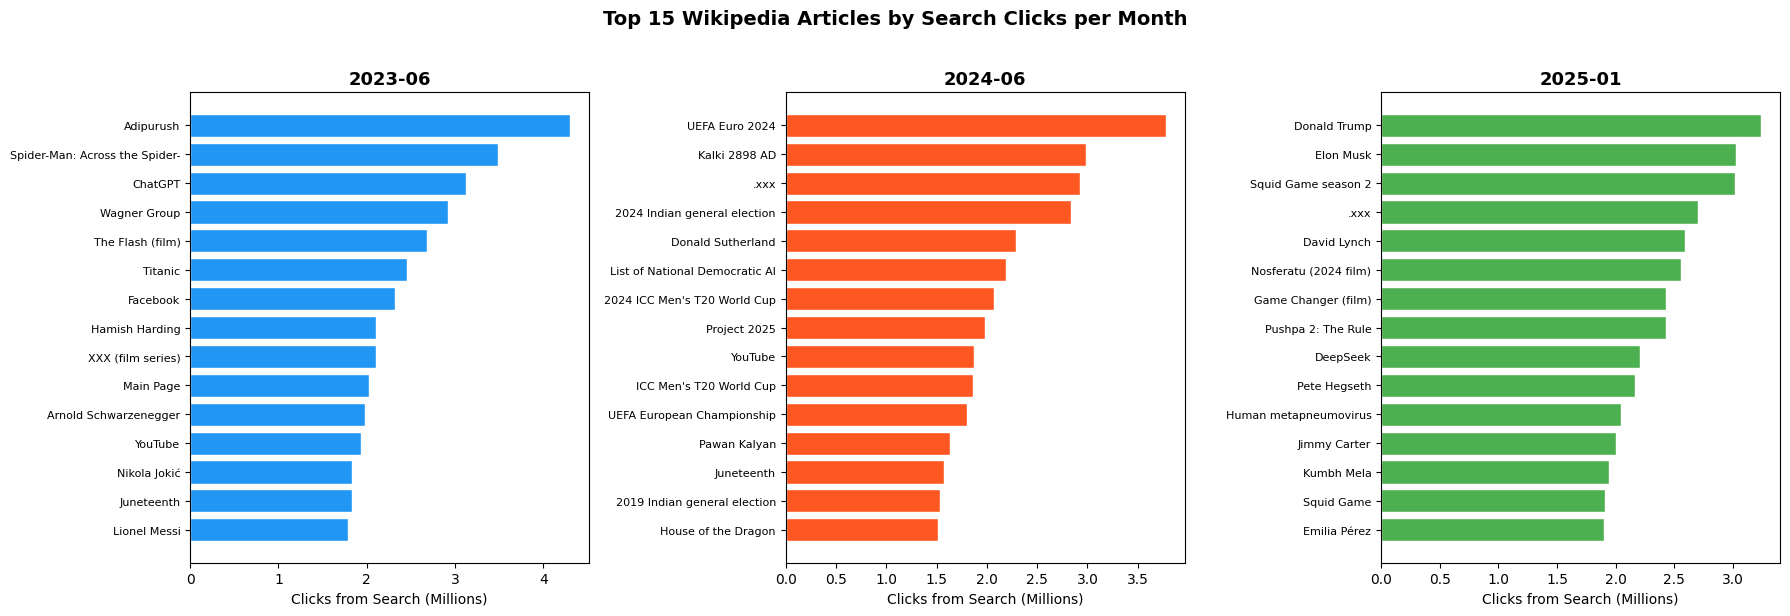

In [10]:
# ------- Figure 2: Top 15 articles by search clicks per month -------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
months = sorted(cs_by_article['month'].unique())

for ax, m, color in zip(axes, months, ['#2196F3', '#FF5722', '#CDDC39']):
    top = cs_by_article[cs_by_article['month'] == m].nlargest(15, 'clicks_from_search')
    top_sorted = top.sort_values('clicks_from_search')
    labels = [t.replace('_', ' ')[:30] for t in top_sorted['curr']]
    ax.barh(labels, top_sorted['clicks_from_search'] / 1e6, color=color, edgecolor='white')
    ax.set_xlabel('Clicks from Search (Millions)', fontsize=10)
    ax.set_title(m, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top 15 Wikipedia Articles by Search Clicks per Month', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

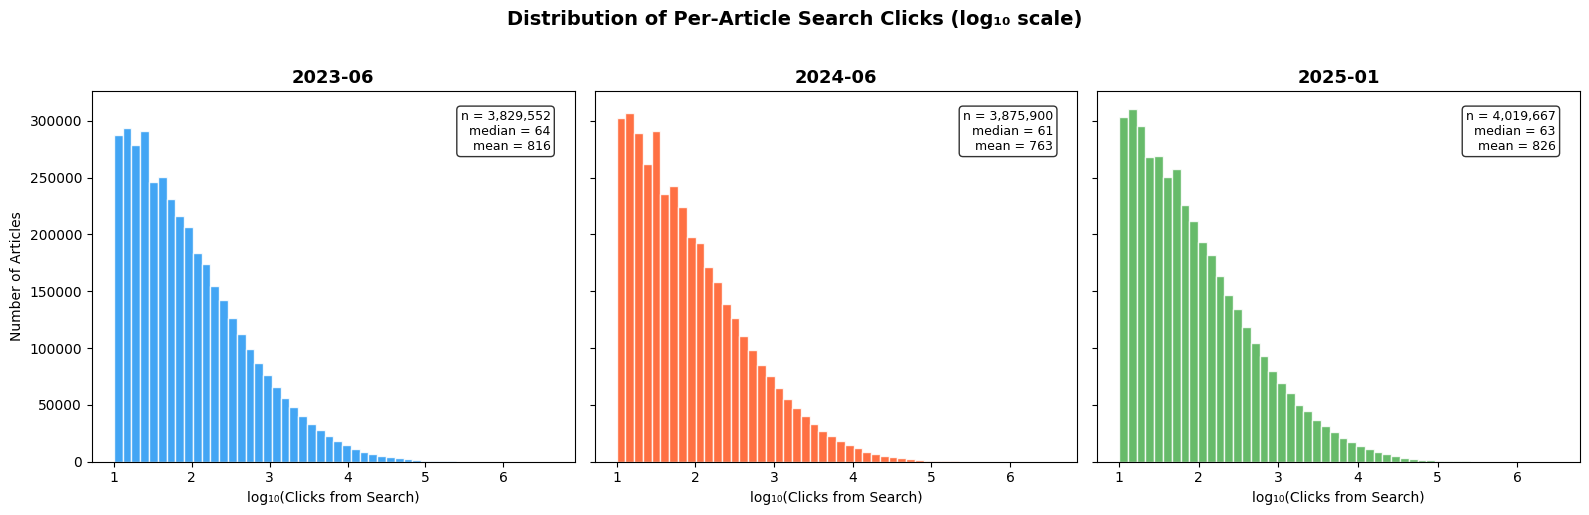

The distributions are heavily right-skewed: most articles receive a small number of search clicks,
while a few high-traffic articles (Main_Page, current events) receive millions.


In [11]:
# ------- Figure 3: Distribution of per-article search clicks (log scale) -------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, m, color in zip(axes, months, ['#2196F3', '#FF5722', '#CDDC39']):
    data = cs_by_article[cs_by_article['month'] == m]['clicks_from_search']
    ax.hist(np.log10(data.clip(lower=1)), bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('log₁₀(Clicks from Search)', fontsize=10)
    ax.set_title(m, fontsize=13, fontweight='bold')
    ax.text(0.95, 0.95, f'n = {len(data):,}\nmedian = {data.median():,.0f}\nmean = {data.mean():,.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Number of Articles', fontsize=10)
fig.suptitle('Distribution of Per-Article Search Clicks (log₁₀ scale)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("The distributions are heavily right-skewed: most articles receive a small number of search clicks,")
print("while a few high-traffic articles (Main_Page, current events) receive millions.")

#### Section 2: Google Trends — Search Interest Stability

A key assumption of our analysis is that search interest in our selected informational topics remained stable across the study period. If interest dropped, a decline in Wikipedia clicks could reflect lower demand rather than AI Overviews intercepting traffic. We use Google Trends weekly data to verify this assumption. We plot interest over time for each keyword and add a vertical line at the AI Overviews rollout (May 2024).

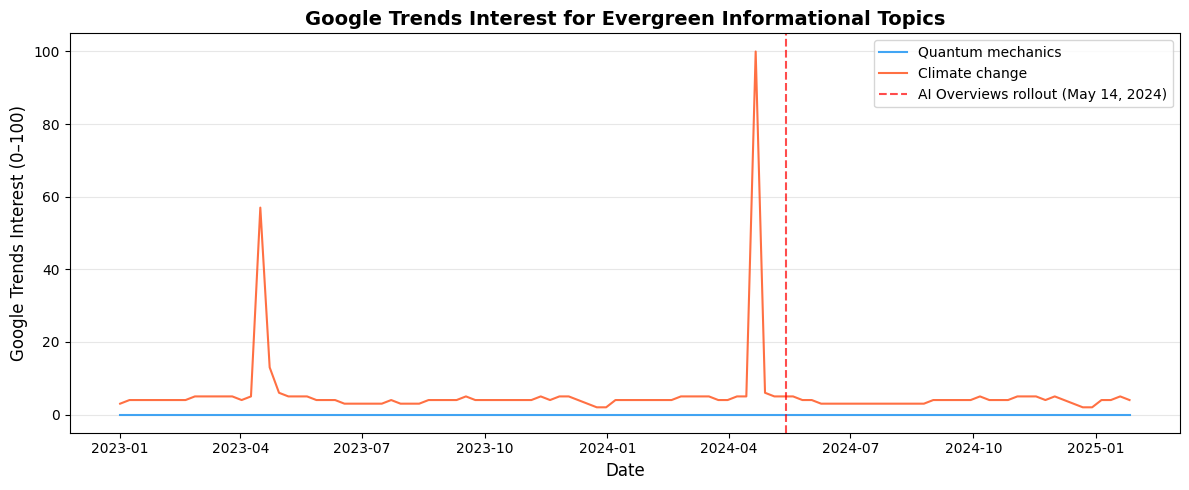


Google Trends summary statistics (pre vs post AI Overviews):


mean  median    std
keyword           period                       
Climate change    Post-AIO  3.73     4.0   0.84
                  Pre-AIO   6.35     4.0  12.87
Quantum mechanics Post-AIO  0.00     0.0   0.00
                  Pre-AIO   0.00     0.0   0.00


Stability check (|post median - pre median| <= 5):


period,Post-AIO,Pre-AIO,abs_median_change,stable_for_analysis
keyword,,,,
Climate change,4.0,4.0,0.0,True
Quantum mechanics,0.0,0.0,0.0,True



Stable evergreen topics used for combined analysis: ['Climate change', 'Quantum mechanics']


In [12]:
# Load Google Trends data
trends_path = 'data/02-processed/google_trends_interest_long.csv'
if os.path.exists(trends_path):
    trends_long = pd.read_csv(trends_path)
    trends_long['date'] = pd.to_datetime(trends_long['date'])
else:
    print("No Trends data found. Run the Google Trends cell above first.")
    trends_long = pd.DataFrame()

# Explicit evergreen operationalization for this checkpoint
# (limited to topics with available Trends + clickstream mappings)
evergreen_topics = {
    'Quantum mechanics': 'Quantum_mechanics',
    'Climate change': 'Climate_change'
}

if not trends_long.empty:
    trends_focus = trends_long[trends_long['keyword'].isin(evergreen_topics.keys())].copy()

    # ------- Figure 4: Google Trends interest over time -------
    fig, ax = plt.subplots(figsize=(12, 5))
    keywords = trends_focus['keyword'].unique()
    palette = {'Quantum mechanics': '#673AB7', 'Climate change': '#4CAF50'}

    for kw in keywords:
        kw_data = trends_focus[trends_focus['keyword'] == kw].sort_values('date')
        ax.plot(kw_data['date'], kw_data['interest'], label=kw,
                color=palette.get(kw, '#666'), linewidth=1.5, alpha=0.85)

    ax.axvline(pd.Timestamp('2024-05-14'), color='FF5722', linestyle='--', alpha=0.7,
               label='AI Overviews rollout (May 14, 2024)')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Google Trends Interest (0–100)', fontsize=12)
    ax.set_title('Google Trends Interest for Evergreen Informational Topics', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Explicit stability rule for topic inclusion:
    # stable if |post median - pre median| <= 5 Trends points.
    trends_focus['period'] = np.where(trends_focus['date'] < '2024-05-14', 'Pre-AIO', 'Post-AIO')
    summary = trends_focus.groupby(['keyword', 'period'])['interest'].agg(['mean', 'median', 'std']).round(2)
    med_table = summary['median'].unstack('period')
    med_table['abs_median_change'] = (med_table['Post-AIO'] - med_table['Pre-AIO']).abs()
    med_table['stable_for_analysis'] = med_table['abs_median_change'] <= 5

    stable_keywords = med_table.index[med_table['stable_for_analysis']].tolist()

    print("\nGoogle Trends summary statistics (pre vs post AI Overviews):")
    display(summary)
    print("\nStability check (|post median - pre median| <= 5):")
    display(med_table)
    print("\nStable evergreen topics used for combined analysis:", stable_keywords)
else:
    trends_focus = pd.DataFrame()
    stable_keywords = []

#### Section 3: Combined Analysis — Operationalized Evergreen Topic Test

We now run the analysis that is directly aligned to the research question:

1. Restrict clickstream to selected evergreen informational article titles.
2. Keep only topics that pass the explicit Trends stability rule from Section 2.
3. Merge by month at the topic level and compute a normalized metric: **clicks per unit of interest**.

This section is exploratory (EDA), so results are directional and not treated as formal significance testing.

Combined topic-level dataset (stable evergreen topics only):


,month,curr,clicks_from_search,keyword,interest,clicks_per_interest,period
0,2023-06,Climate_change,38129.0,Climate change,3.50,10894.000000,Pre-AIO
1,2023-06,Quantum_mechanics,52078.0,Quantum mechanics,0.00,520780.000000,Pre-AIO
2,2024-06,Climate_change,46098.0,Climate change,3.20,14405.625000,Post-AIO
3,2024-06,Quantum_mechanics,55427.0,Quantum mechanics,0.00,554270.000000,Post-AIO
4,2025-01,Climate_change,44541.0,Climate change,4.25,10480.235294,Post-AIO
5,2025-01,Quantum_mechanics,65408.0,Quantum mechanics,0.00,654080.000000,Post-AIO



Monthly aggregate for visualization:


,month,wiki_clicks,interest,clicks_per_interest,period
0,2023-06,90207.0,1.750,265837.000000,Pre-AIO
1,2024-06,101525.0,1.600,284337.812500,Post-AIO
2,2025-01,109949.0,2.125,332280.117647,Post-AIO


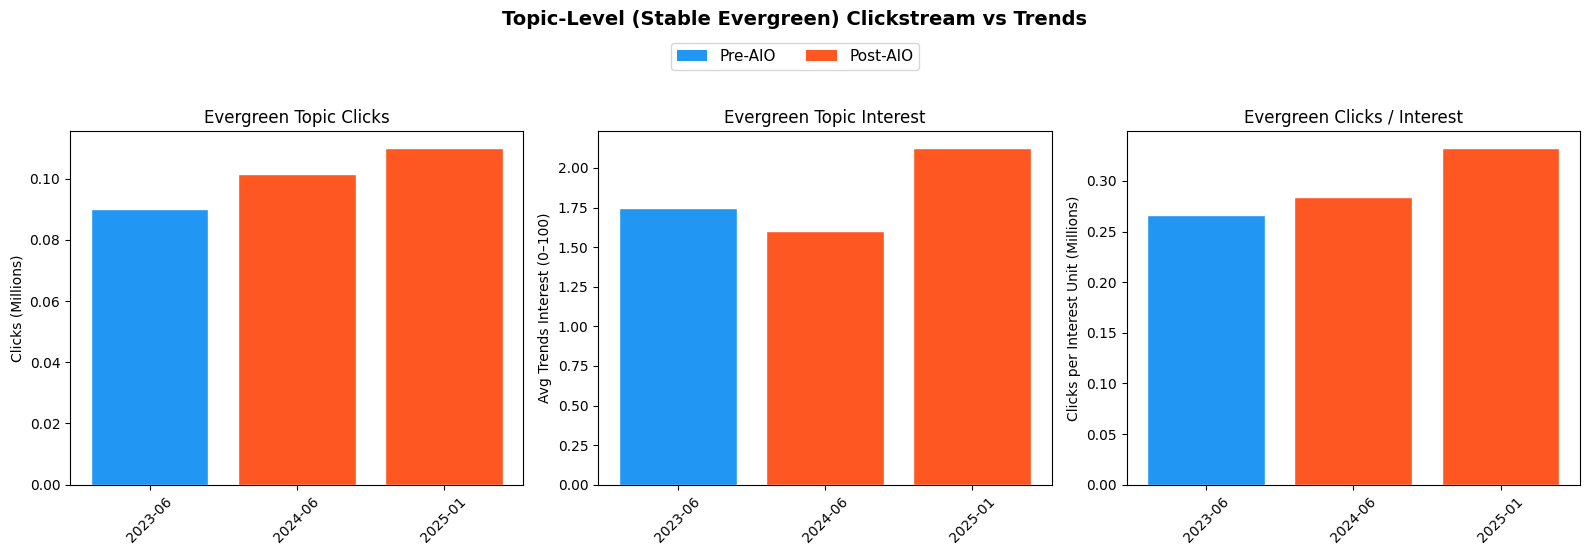

In [13]:
# Operationalized combined analysis at topic level
cs_by_article = pd.read_csv('data/02-processed/wikipedia_clickstream_search_by_month_article.csv')

if not trends_focus.empty and len(stable_keywords) > 0:
    # Map topic labels to clickstream article titles
    article_for_keyword = {k: v for k, v in evergreen_topics.items()}

    # Topic-level clickstream (evergreen + stable topics only)
    stable_articles = [article_for_keyword[k] for k in stable_keywords if k in article_for_keyword]
    cs_topic = cs_by_article[cs_by_article['curr'].isin(stable_articles)].copy()
    reverse_map = {v: k for k, v in article_for_keyword.items()}
    cs_topic['keyword'] = cs_topic['curr'].map(reverse_map)

    # Topic-level trends monthly
    trends_topic = trends_focus[trends_focus['keyword'].isin(stable_keywords)].copy()
    trends_topic['month'] = trends_topic['date'].dt.to_period('M').astype(str)
    trends_topic_monthly = trends_topic.groupby(['month', 'keyword'], as_index=False)['interest'].mean()

    # Merge topic-month pairs
    combined_topic = cs_topic.merge(
        trends_topic_monthly,
        left_on=['month', 'keyword'],
        right_on=['month', 'keyword'],
        how='inner'
    )
    combined_topic['clicks_per_interest'] = combined_topic['clicks_from_search'] / combined_topic['interest'].clip(lower=0.1)
    combined_topic['period'] = np.where(combined_topic['month'] < '2024-05', 'Pre-AIO', 'Post-AIO')

    # Aggregate across stable evergreen topics by month
    combined_monthly = combined_topic.groupby('month', as_index=False).agg(
        wiki_clicks=('clicks_from_search', 'sum'),
        interest=('interest', 'mean'),
        clicks_per_interest=('clicks_per_interest', 'mean')
    )
    combined_monthly['period'] = np.where(combined_monthly['month'] < '2024-05', 'Pre-AIO', 'Post-AIO')

    print("Combined topic-level dataset (stable evergreen topics only):")
    display(combined_topic.head(10))
    print("\nMonthly aggregate for visualization:")
    display(combined_monthly)

    # ------- Figure 5: Combined bar chart — clicks, interest, ratio -------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    period_colors = {'Pre-AIO': '#2196F3', 'Post-AIO': '#FF5722'}
    bar_colors = [period_colors[p] for p in combined_monthly['period']]

    axes[0].bar(combined_monthly['month'], combined_monthly['wiki_clicks'] / 1e6, color=bar_colors, edgecolor='white')
    axes[0].set_ylabel('Clicks (Millions)')
    axes[0].set_title('Evergreen Topic Clicks')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(combined_monthly['month'], combined_monthly['interest'], color=bar_colors, edgecolor='white')
    axes[1].set_ylabel('Avg Trends Interest (0–100)')
    axes[1].set_title('Evergreen Topic Interest')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].bar(combined_monthly['month'], combined_monthly['clicks_per_interest'] / 1e6, color=bar_colors, edgecolor='white')
    axes[2].set_ylabel('Clicks per Interest Unit (Millions)')
    axes[2].set_title('Evergreen Clicks / Interest')
    axes[2].tick_params(axis='x', rotation=45)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2196F3', label='Pre-AIO'), Patch(facecolor='#FF5722', label='Post-AIO')]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.05))
    fig.suptitle('Topic-Level (Stable Evergreen) Clickstream vs Trends', fontsize=14, fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.show()
else:
    print("Stable topic set unavailable. Check Trends loading/stability step.")

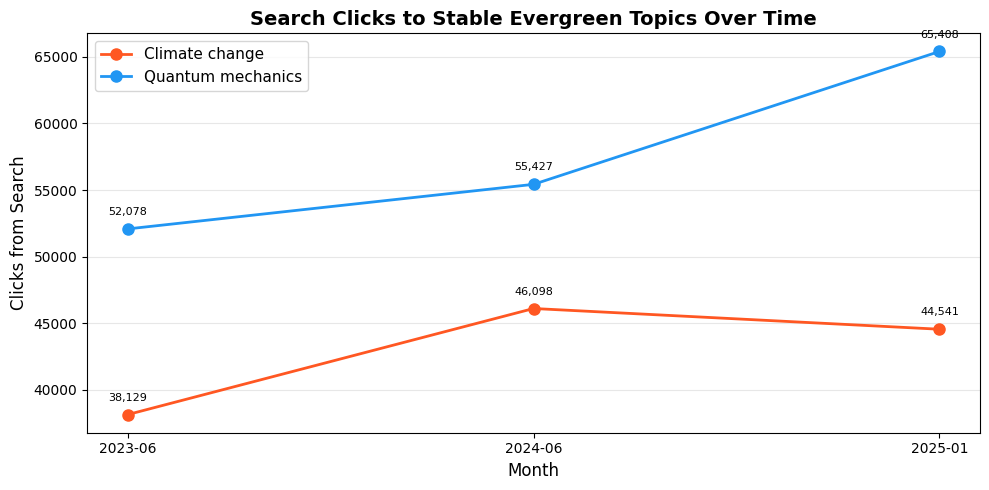

In [14]:
# ------- Figure 6: Per-topic clickstream trajectories for stable evergreen topics -------
cs_by_article = pd.read_csv('data/02-processed/wikipedia_clickstream_search_by_month_article.csv')

if len(stable_keywords) > 0:
    stable_article_map = {evergreen_topics[k]: k for k in stable_keywords if k in evergreen_topics}
    topic_clicks = cs_by_article[cs_by_article['curr'].isin(stable_article_map.keys())].copy()
    topic_clicks['topic'] = topic_clicks['curr'].map(stable_article_map)

    if not topic_clicks.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        topic_palette = {'Quantum mechanics': '#673AB7', 'Climate change': '#4CAF50'}

        for topic in sorted(topic_clicks['topic'].unique()):
            t = topic_clicks[topic_clicks['topic'] == topic].sort_values('month')
            ax.plot(t['month'], t['clicks_from_search'], marker='o', linewidth=2,
                    markersize=8, label=topic, color=topic_palette.get(topic, '#666'))
            for _, row in t.iterrows():
                ax.annotate(f"{row['clicks_from_search']:,.0f}", (row['month'], row['clicks_from_search']),
                            textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Clicks from Search', fontsize=12)
        ax.set_title('Search Clicks to Stable Evergreen Topics Over Time', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Stable evergreen article titles not found in clickstream data.")
else:
    print("No stable keywords passed the criterion; skipping topic trajectory plot.")

#### EDA Summary and Interpretation

**Key findings from the EDA (directional, not confirmatory):**

1. **Contextual aggregate signal:** Total search-to-Wikipedia clicks are lower in June 2024 than June 2023 (~5.4% YoY decline). This is descriptive context only and not the primary operational test.

2. **Skewed traffic distribution:** Per-article click distributions are heavily right-skewed in all snapshots, indicating aggregate results can be dominated by high-traffic pages.

3. **Operationalized topic filtering:** We explicitly define evergreen topics and apply a Trends stability rule (**stable if |post median - pre median| <= 5 points**) before combined analysis.

4. **Topic-level normalized metric:** For stable evergreen topics, we compute clicks-per-interest by month. This provides a better proxy for potential click interception than raw click totals.

**Methodological constraints in this checkpoint:**
- Only 3 clickstream months are available, which is insufficient for formal pre/post significance testing.
- Evergreen topic coverage is currently small (2 mapped topics), so inference is limited.
- Seasonality remains a confound when months are not aligned.

**Next steps for final project correctness:**
- Add more monthly clickstream files (especially continuous months across 2023–2025).
- Expand evergreen topic set and keep the explicit stability rule.
- Run formal statistical tests on aligned monthly panels (with seasonality controls) and report confidence intervals/effect sizes.

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

    >Our datasets present an interesting informed consent situation. While Wikipedia Clickstream and Google Trends data contain no personally identifiable information, the clickstream data originates from real users' browsing behavior — people who navigated from Google to Wikipedia without knowing their behavior would be aggregated and used in research. Wikimedia publishes this data openly under their privacy policy, which users implicitly accept, but true affirmative opt-in consent was never obtained. We consider this an acceptable tradeoff given the data is fully anonymized and aggregated before we ever access it, meaning no individual can be identified. Additionally, there is a reasonable argument that most internet users today have a general awareness that their searches are not private — Google Trends itself is a widely used public tool that many people interact with directly. This awareness has arguably been further reinforced culturally through true crime media, where high-profile cases like Casey Anthony and the Idaho student murders brought mainstream attention to the fact that search histories can be subpoenaed and used as evidence. Whether or not users formally consented, there is broad public understanding that online search behavior leaves a traceable record. Google Trends data raises fewer concerns as it is a deliberately public-facing tool that Google explicitly designed for research and analysis purposes.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

    >Our analysis is intentionally scoped to English-language searches using English Wikipedia Clickstream data, which allows for a more controlled comparison while acknowledging this limits generalizability to non-English-speaking populations. Within this scope, our most significant source of collection bias stems from using Wikipedia Clickstream as a proxy for zero-click behavior. Wikipedia attracts a specific type of user — generally educated, English-speaking, and seeking encyclopedic information — meaning our analysis inherently reflects only a narrow subset of informational queries. Someone searching "how do I renew my license" or "best pizza near me" will never land on Wikipedia regardless of whether AI Overviews exist, so our measure of zero-click behavior is really only valid for a particular class of curiosity-driven informational queries. Additionally, Google Trends normalizes all data to a scale of 0-100 relative to peak interest rather than showing absolute search volume, meaning if overall search volume grew significantly after AI Overviews launched, Trends would not capture that, potentially masking the true scale of behavioral change. Finally, we must be careful about which Wikipedia articles we select, as certain topics introduce noise that has nothing to do with AI Overviews — for example, a celebrity death, a breaking news event, or a viral moment during 2023-2025 would cause an artificial spike or crash in clicks that would contaminate our results. To mitigate this, we will intentionally exclude any topics that experienced major real-world events during our study period and instead restrict our selection to stable, evergreen topics such as major companies, living celebrities who did not die between 2023-2025, and well-established historical events. These topics have consistent baseline search interest, making them a much cleaner signal for detecting whether AI Overviews are intercepting traffic.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

    >Our datasets contain no personally identifiable information at any level. Wikipedia Clickstream data is purely aggregate click counts with no user or location data attached. While Google Trends allows filtering by region, we will not be using location-based filtering in our analysis, meaning we never interact with even aggregate location data. There is no PII exposure risk in this project.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
    >Data files will be deleted from local machines after the project concludes in March 2026.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
    >We did not formally engage with outside stakeholders or domain experts during the development of this project. The perspectives most notably absent are those of anyone who creates content for the web and depends on organic search traffic to reach an audience — this includes bloggers, journalists, writers, photographers, UX designers, and anyone who has built a website whether through custom development or platforms like Wix or Squarespace. These are the people most directly and economically harmed by the trends we are studying, as reduced organic clicks means fewer people ever reach their work. SEO professionals who track click-through rates professionally would also have been valuable consultants for validating our methodology. We acknowledge these missing perspectives as a limitation of our analysis, and note that our conclusions should be interpreted with the understanding that they were not reviewed by those with firsthand experience of the phenomenon we are studying.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

    >Our most significant dataset bias is that we are exclusively using English Wikipedia Clickstream data and English-language Google Trends queries, meaning our findings only reflect the behavior of English-speaking users. This is an intentional scope decision rather than an oversight, but it does mean our conclusions cannot be generalized to non-English-speaking populations who may interact with AI Overviews very differently. Confirmation bias is also worth acknowledging — given that our hypothesis already predicts that AI Overviews will reduce organic clicks, we must be careful not to selectively interpret our findings in ways that support that conclusion. We will mitigate this by letting the statistical tests drive our conclusions rather than cherry-picking time periods or topics that support our hypothesis. There are also meaningful confounding variables that could explain drops in Wikipedia clicks that have nothing to do with AI Overviews. One notable example is the growing awareness around source reliability and media literacy — as more people learn about evaluating credible sources, Wikipedia's reputation as an anyone-can-edit platform may lead fewer people to click through to it regardless of whether AI Overviews exist. This cultural shift toward skepticism of Wikipedia as a reliable source could independently reduce click traffic in our study period and be mistakenly attributed to AI Overviews. We will attempt to account for confounding variables by comparing trends across multiple topics and looking for consistent patterns rather than relying on any single data point.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
    >We are committed to honestly representing our data in all visualizations and summary statistics. This means we will not manipulate axis scales, cherry-pick time ranges, or present results in misleading ways. If our findings do not support our hypothesis, we will report that honestly rather than adjusting our analysis to fit our expectations.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
    >Our entire analysis will be documented and reproducible through our public GitHub repository. All data cleaning, wrangling, and statistical analysis will be conducted in Jupyter notebooks with clear explanations of each step. Anyone should be able to clone our repository, download the same publicly available datasets from Wikipedia Clickstream and Google Trends, and reproduce our exact results.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

- **Communication:** Primarily via iMessage group chat; meet via FaceTime or in person as needed. Respond within 24 hours; notify in advance if unable to attend a meeting.
- **Equal contribution:** Each member contributes equally across research, coding, writing, and editing; we rotate responsibilities.
- **Tone and respect:** Blunt but polite; use "I statements" when giving feedback; assume criticism is well-intentioned.
- **Task management:** Use GitHub for tasks and deadlines; assign fairly by strengths and availability. If struggling, notify within 48 hours to redistribute.
- **Decision making:** Majority vote for major decisions; for urgent decisions when someone is unresponsive, available members can proceed and update afterward.
- **Accountability:** If someone is not meeting expectations, address directly (e.g. via text) with one week to improve and specific deliverables; redistribute tasks as needed.
- **Deadlines:** Internal deadlines 2–3 days before official course deadlines for review and revision.

## Project Timeline Proposal

**Special resources/training:** Statistical methods for pre/post AI Overviews comparison (e.g. t-tests, chi-square); clear visualizations for trends over time.

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|--------------|--------------|--------------------------|-------------------|
| 1/15 | 12 PM | NA | Determine best form of communication |
| 1/23 | 10 AM | Brainstorm topics (All) | Brainstorm topics (All) |
| 1/26 | 10 AM | Background research (Ali, Rodayna); Ethics draft (Sabine) | Ideal dataset(s) and ethics; draft proposal |
| 2/4 | 10 AM | Edit, finalize, submit proposal (Maanav, Tessa); Search datasets (All) | Wrangling and analysis approaches; assign leads |
| 2/4 | Before 11:59 PM | NA | **Turn in Project Proposal** |
| 2/14 | 6 PM | Import & wrangle data (Maanav); Initial EDA with 3+ visualizations (Rodayna) | Review wrangling/EDA; analysis plan; data quality |
| 2/14 | Before 11:59 PM | NA | **Turn in Data Checkpoint** |
| 2/23 | 12 PM | Finalize wrangling/EDA (Maanav, Rodayna); Begin pre/post statistical analysis (Sabine, Tessa) | Edit analysis; preliminary results; check-in |
| 3/2 | 12 PM | Complete hypothesis testing (Sabine, Tessa); Initial results visualizations (Rodayna); Code review (Maanav) | Review statistical findings; assign final visualization tasks |
| 3/4 | Before 11:59 PM | NA | **Turn in EDA Checkpoint** |
| 3/9 | 12 PM | Finalize analysis and visualizations; Draft results/conclusion (Ali); Polish notebook (Maanav) | Review analysis; edit results/discussion; video outline |
| 3/13 | 12 PM | Ethics updates (Sabine); Finalize written sections (Ali, Tessa); Record video segments (All) | Integrate video; final review |
| 3/18 | Before 11:59 PM | NA | **Turn in Final Project & Video** |

*Timeline updated for EDA Checkpoint: EDA complete with 6 figures across 3 sections (clickstream trends, Trends stability, combined analysis). Next steps: acquire more monthly clickstream files, expand keyword list, run formal statistical tests for the final project.*